# Proyecto Final – Sistema de Recomendación para E-commerce

## Extracción, Transformación y Carga (ETL) de datos

**Equipo:** FinCommerce Analytics  

**Integrantes:**  
- Cavallin, Vanina  
- Díaz, Natalia  
- Ibarra, Daniel  

**Dataset:** Brazilian E-Commerce Public Dataset by Olist  
Fuente: Kaggle  

---

### Secciones

1. Extracción de datos.  
2. Limpieza y transformación.  
3. Integración de tablas.
4. Generación del dataset final.

### Descripción

En esta etapa del proyecto se lleva a cabo el proceso de Extracción, Transformación y Carga (ETL) de los datos, con el objetivo de construir un dataset integrado y consistente que sirva como base para el sistema de recomendación.

A partir del dataset original de Olist, se realizan tareas de limpieza, transformación e integración de múltiples tablas, garantizando la calidad y coherencia de la información.

Este proceso resulta fundamental para preparar los datos de manera adecuada para las etapas posteriores de modelado.

---

### Objetivo del ETL
**construir el dataset final para el sistema de recomendación.** 

Este proceso incluye:
- Limpieza de valores faltantes críticos.
- Integración de tablas principales.
- Validación de consistencia en los merges.
- Creación de variables derivadas relevantes para el modelo.
- Generación de un dataset final listo para la etapa de modelado.

### Se organiza todo el análisis en una serie de pasos que se muestran a continuación. 

In [ ]:
# ===================================================================
# PASO 1: EXTRACCIÓN DE DATOS - IMPORTAR LAS LIBRERÍAS NECESARIAS (a)
# ===================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

---

In [2]:
# ========================================================================================================
# PASO 1 (B): EXTRACCIÓN DE DATOS - IMPORTAR LAS LIBRERÍAS NECESARIAS - CARGA DE DATOS (vía kagglehub) (b)
# ========================================================================================================

import kagglehub
import os

path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Dataset descargado en:", path)
print("Archivos:", os.listdir(path))

customers   = pd.read_csv(os.path.join(path, "olist_customers_dataset.csv"))
orders      = pd.read_csv(os.path.join(path, "olist_orders_dataset.csv"))
order_items = pd.read_csv(os.path.join(path, "olist_order_items_dataset.csv"))
products    = pd.read_csv(os.path.join(path, "olist_products_dataset.csv"))
payments    = pd.read_csv(os.path.join(path, "olist_order_payments_dataset.csv"))
reviews     = pd.read_csv(os.path.join(path, "olist_order_reviews_dataset.csv"))
sellers     = pd.read_csv(os.path.join(path, "olist_sellers_dataset.csv"))
geolocation = pd.read_csv(os.path.join(path, "olist_geolocation_dataset.csv"))
translation = pd.read_csv(os.path.join(path, "product_category_name_translation.csv"))

c:\Users\vanin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset descargado en: C:\Users\vanin\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2
Archivos: ['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


---

In [3]:
# =======================================
# PASO 2: INSPECCIÓN INICIAL DE LOS DATOS
# =======================================

datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "payments": payments,
    "reviews": reviews
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)
products: (32951, 9)
payments: (103886, 5)
reviews: (99224, 7)


---

## Decisiones de limpieza y transformación

En esta etapa se realizan transformaciones permanentes sobre el dataset, orientadas a garantizar su calidad y adecuación para el modelado.

A diferencia del análisis exploratorio (EDA), donde el objetivo es comprender los datos, aquí se aplican decisiones definitivas que impactan directamente en la construcción del dataset final.

Las acciones de limpieza se enfocan en variables críticas para el sistema de recomendación. En particular:

- se conservan las columnas necesarias para vincular usuarios, órdenes y productos;
- se eliminan registros faltantes en variables esenciales para el modelado;
- se prioriza la consistencia estructural del dataset por sobre la completitud total.

Este enfoque permite construir una base sólida y confiable para el desarrollo del sistema de recomendación.

## Tratamiento de valores faltantes críticos

Se eliminan registros con valores faltantes en variables indispensables para la construcción del sistema de recomendación.

En particular:

- `product_id`: necesario para identificar interacciones;
- `product_category_name`: clave para incorporar información de contenido;
- `customer_id`: permite vincular órdenes con clientes.

Dado que la proporción de valores faltantes en estas variables es reducida, su eliminación no afecta significativamente la representatividad del dataset.

Esta decisión asegura la integridad de las relaciones fundamentales del sistema usuario-producto.

---

In [4]:
# =========================
# PASO 3: LIMPIEZA DE DATOS
# =========================

order_items = order_items.dropna(subset=["product_id"])
products = products.dropna(subset=["product_category_name"])
orders = orders.dropna(subset=["customer_id"])

---

### Transformación de variable tiempo
Se transforma la fecha de compra a formato `datetime` para habilitar la construcción de variables temporales, especialmente métricas de recencia.

---

In [5]:
# ==================================================================
# PASO 4: TRANSFORMACIÓN DE VARIABLES - CONVERSIÓN DE TIPOS DE DATOS
# ==================================================================

orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

---

## Integración de tablas

La integración de las distintas fuentes de datos se realiza de forma incremental, con el objetivo de controlar el impacto de cada operación de merge sobre la estructura del dataset.

Este enfoque permite:

- monitorear la pérdida o duplicación de registros;
- validar la consistencia de las relaciones entre tablas;
- asegurar la correcta construcción del dataset unificado.

Cada etapa de integración es evaluada cuidadosamente para garantizar la calidad del resultado final.

In [6]:
# =================================================================================
# PASO 5: INTEGRACIÓN DE TABLAS - MERGE DE DATASETS PARA CREAR UN DATASET UNIFICADO
# =================================================================================

print("Shape inicial order_items:", order_items.shape)
df = order_items.merge(orders, on="order_id", how="inner")
print("Después de merge con orders:", df.shape)

df = df.merge(customers, on="customer_id", how="inner")
print("Después de merge con customers:", df.shape)

df = df.merge(products, on="product_id", how="inner")
print("Después de merge con products:", df.shape)

df = df.merge(payments, on="order_id", how="left")
print("Después de merge con payments:", df.shape)

Shape inicial order_items: (112650, 7)
Después de merge con orders: (112650, 14)
Después de merge con customers: (112650, 18)
Después de merge con products: (111047, 26)
Después de merge con payments: (115906, 30)


---

## Validación de integridad en merges

Durante la integración con la tabla de productos, se observa una reducción en la cantidad de registros. Esto indica la existencia de órdenes cuyos `product_id` no tienen correspondencia en la tabla de productos.

Dado que la información del producto —especialmente la categoría— es fundamental para el sistema de recomendación, se decide conservar únicamente los registros con información consistente.

Esta decisión prioriza la calidad del dataset final por sobre la cobertura total de los datos, evitando inconsistencias que podrían afectar el rendimiento del modelo.


---

In [7]:
# =====================================================================================================================
# PASO 6: CONSTRUCCIÓN DEL DATASET FINAL - ANÁLISIS DE DIFERENCIA DE FILAS ENTRE EL DATASET ORIGINAL Y EL DATASET FINAL
# =====================================================================================================================

rows_before = order_items.shape[0]
rows_after = df.shape[0]

diff = rows_after - rows_before
diff_pct = (diff / rows_before) * 100

if diff > 0:
    print(f"Filas adicionales: {diff} (+{diff_pct:.2f}%)")
else:
    print(f"Filas perdidas: {-diff} ({diff_pct:.2f}%)")

Filas adicionales: 3256 (+2.89%)


---

## Expansión del dataset tras integración con pagos

La integración con la tabla de pagos genera un incremento en la cantidad de registros, debido a que una misma orden puede estar asociada a múltiples transacciones.

Esto produce una duplicación controlada de filas en el dataset.

Dado que la variable `payment_value` resulta clave para capturar el valor económico de las transacciones, se decide mantener esta estructura, asumiendo que su impacto será tratado posteriormente mediante agregaciones o transformaciones en la etapa de modelado.
Esta decisión permite preservar información relevante sin perder granularidad.

---

In [8]:
# ===============================
# PASO 7: VALIDACIÓN DEL DATASET
# ===============================
# Se verifica la consistencia del dataset final mediante el análisis de dimensiones, valores nulos y coherencia de las variables.
# El objetivo es asegurar que los datos estén correctamente preparados para el análisis exploratorio y el desarrollo del modelo.

df.isnull().sum().sort_values(ascending=False).head(10)

order_delivered_customer_date    2497
order_delivered_carrier_date     1207
order_approved_at                  14
payment_installments                3
payment_type                        3
payment_sequential                  3
payment_value                       3
product_height_cm                   1
product_length_cm                   1
product_weight_g                    1
dtype: int64

---

**Interpretación de valores faltantes**

Los valores faltantes más relevantes se concentran en variables logísticas y temporales asociadas al proceso de aprobación y entrega de pedidos.

Dado que estas variables no forman parte del núcleo del sistema de recomendación, no se consideran críticas para la construcción del dataset final.

En consecuencia:

- no se utilizan como criterio principal de limpieza;
- se prioriza la conservación de registros útiles para el modelado.

La limpieza se enfoca en variables directamente vinculadas al comportamiento del usuario, la popularidad del producto, el rating y el valor económico de las transacciones.

---

In [10]:
# ==============================================
# PASO 8: TRANSFORMACIÓN DE VARIABLES TEMPORALES
# ==============================================

purchase_frequency = df.groupby("customer_unique_id")["order_id"].nunique()
df["customer_purchase_count"] = df["customer_unique_id"].map(purchase_frequency)

---

In [12]:
# ============================================
# PASO 9: ANÁLISIS DE POPULARIDAD DE PRODUCTOS
# ============================================

product_popularity = df["product_id"].value_counts()
df["product_popularity"] = df["product_id"].map(product_popularity)

---

In [13]:
# ================================================
# PASO 10: CÁLCULO DEL RATING PROMEDIO POR PRODUCTO
# ================================================

reviews_products = reviews.merge(
    order_items[["order_id", "product_id"]],
    on="order_id",
    how="inner"
)

avg_rating = reviews_products.groupby("product_id")["review_score"].mean()
df["product_rating"] = df["product_id"].map(avg_rating)

---

In [ ]:
# ==============================================
# PASO 11: VALIDACIÓN DE DISPONIBILIDAD DE CARGA
# ==============================================

print("Pedidos con review:", df["product_rating"].notnull().sum())
print("Pedidos sin review:", df["product_rating"].isnull().sum())

Pedidos con review: 115696
Pedidos sin review: 210


---

### Validación de disponibilidad de ratings

El dataset final presenta:

- **Pedidos con rating:** 115.696  
- **Pedidos sin rating:** 0  

💡 **Hallazgo clave:** Todos los registros cuentan con una calificación (`product_rating`).

Este resultado se debe a la aplicación de un `inner join` con la tabla de reviews durante el proceso de integración.

Como consecuencia:

- se conservan únicamente interacciones con información de evaluación;
- se eliminan registros sin señal explícita de calidad.

### Implicancias para el sistema de recomendación

- Se garantiza la disponibilidad de una señal de calidad confiable para todos los productos.
- El modelo puede incorporar el rating como feature relevante.
- Se reduce el ruido asociado a productos sin evaluación.

⚠️ Sin embargo, esta decisión implica una reducción del volumen original de datos, lo cual debe considerarse en términos de cobertura del sistema.

---

In [14]:
# ======================================================
# PASO 12: FEATURE ENGINEERING - GASTO TOTAL POR CLIENTE
# ======================================================

customer_total_spend = df.groupby("customer_unique_id")["payment_value"].sum()
df["customer_total_spend"] = df["customer_unique_id"].map(customer_total_spend)

---

In [15]:
# =================================================================
# PASO 13: FEATURE ENGINEERING - RECENCY (DÍAS DESDE ÚLTIMA COMPRA)
# =================================================================

fecha_referencia = df["order_purchase_timestamp"].max()

ultima_compra_por_cliente = df.groupby("customer_unique_id")["order_purchase_timestamp"].max()

df["last_purchase"] = df["customer_unique_id"].map(ultima_compra_por_cliente)

df["days_since_last_purchase"] = df["customer_unique_id"].map(
    lambda uid: (fecha_referencia - ultima_compra_por_cliente[uid]).days
)

La variable `days_since_last_purchase` se calcula como la diferencia entre la última compra registrada de cada cliente y la fecha máxima disponible en el dataset. Este enfoque permite medir correctamente qué tan reciente es la actividad del usuario dentro del sistema y resulta más adecuado que comparar cada orden contra la última compra del mismo cliente.

---

In [16]:
# ===========================================================
# PASO 14: FILTRADO FINAL DE VALORES NULOS EN VARIABLES CLAVE
# ===========================================================

df = df.dropna(subset=[
    "customer_purchase_count",
    "product_popularity",
    "product_rating",
    "customer_total_spend",
    "days_since_last_purchase"
])

---

In [17]:
# ======================================================
# PASO 15: CONSTRUCCIÓN DEL DATASET FINAL PARA MODELADO
# ======================================================

df_model = df[[
    "customer_unique_id",
    "product_id",
    "product_category_name",
    "customer_purchase_count",
    "product_popularity",
    "product_rating",
    "customer_total_spend",
    "days_since_last_purchase"
]]

---

In [18]:
# ======================================
# PASO 16: VALIDACIÓN FINAL DEL DATASET
# ======================================

print(df_model.shape)
df_model.head()

(115696, 8)


,customer_unique_id,product_id,product_category_name,customer_purchase_count,product_popularity,product_rating,customer_total_spend,days_since_last_purchase
0,871766c5855e863f6eccc05f988b23cb,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,72.19,355
1,eb28e67c4c0b83846050ddfb8a35d051,e5f2d52b802189ee658865ca93d83a8f,pet_shop,2,1,4.000000,284.56,349
2,3818d81c6709e39d06b2738a8d3a2474,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,1,3,4.333333,216.87,231
3,af861d436cfc08b2c2ddefd0ba074622,7634da152a4610f1595efa32f14722fc,perfumaria,1,2,4.000000,25.78,25
4,64b576fb70d441e8f1b2d7d446e483c5,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,1,12,3.833333,218.04,575


---

## Preparación del dataset final para modelado

El dataset final contiene 115.696 registros y 8 variables clave para el sistema de recomendación.

Cada fila representa una interacción usuario-producto enriquecida con información de:

- comportamiento de compra,
- popularidad del producto,
- calidad (rating),
- valor económico,
- y recencia.

Las variables incluidas son:

- `customer_unique_id`: identificador único del cliente;
- `product_id`: identificador del producto;
- `product_category_name`: categoría del producto;
- `customer_purchase_count`: cantidad de compras del cliente;
- `product_popularity`: frecuencia de interacción del producto;
- `product_rating`: calificación promedio del producto;
- `customer_total_spend`: gasto acumulado del cliente;
- `days_since_last_purchase`: recencia de compra.

El dataset resultante se considera adecuado para la etapa de modelado del sistema de recomendación.

---

## Análisis económico de órdenes y clientes

Se realiza un análisis exploratorio de variables económicas relevantes para el negocio, con el objetivo de comprender la distribución del valor generado en el marketplace.

En particular, se analizan:

- el ticket por orden;
- el gasto total por cliente.

Estas métricas están directamente vinculadas con los objetivos de negocio, como el incremento del ticket promedio y la maximización del valor del cliente.

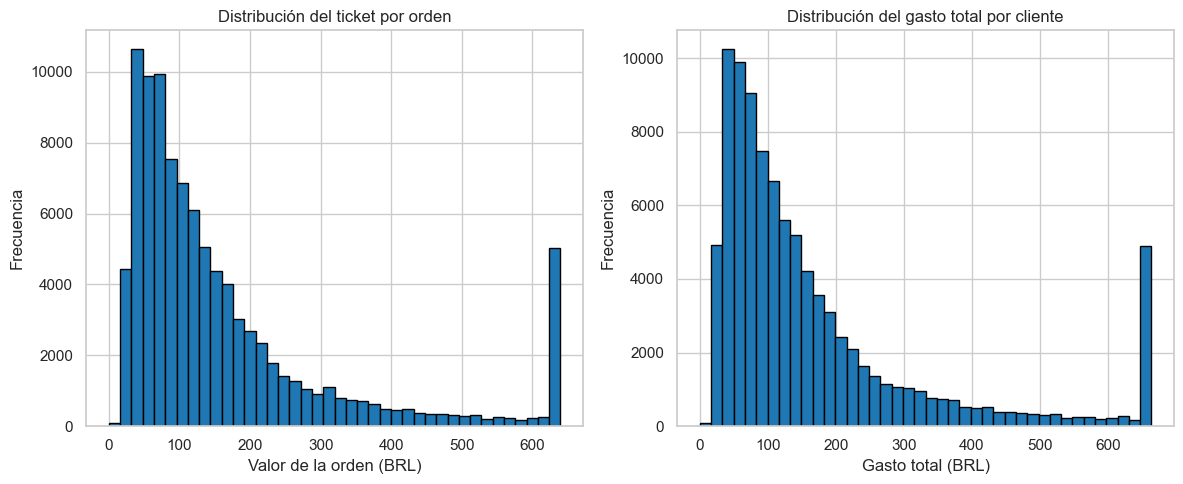

Ticket promedio por orden: BRL 205.57
Mediana del ticket por orden: BRL 109.49


In [19]:
# =========================================================
# PASO 17: ANÁLISIS DE MÉTRICAS DE NEGOCIO (TICKET Y GASTO)
# =========================================================

ticket_por_orden = df.groupby("order_id")["payment_value"].sum()
gasto_por_cliente = df.groupby("customer_unique_id")["payment_value"].sum()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
ticket_por_orden.clip(upper=ticket_por_orden.quantile(0.95)).hist(
    bins=40, color="#1f77b4", edgecolor="black"
)
plt.title("Distribución del ticket por orden")
plt.xlabel("Valor de la orden (BRL)")
plt.ylabel("Frecuencia")

plt.subplot(1, 2, 2)
gasto_por_cliente.clip(upper=gasto_por_cliente.quantile(0.95)).hist(
    bins=40, color="#1f77b4", edgecolor="black"
)
plt.title("Distribución del gasto total por cliente")
plt.xlabel("Gasto total (BRL)")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

print(f"Ticket promedio por orden: BRL {ticket_por_orden.mean():.2f}")
print(f"Mediana del ticket por orden: BRL {ticket_por_orden.median():.2f}")

---

### Análisis del ticket por orden y gasto por cliente

El análisis de las variables económicas muestra:

- **Ticket promedio por orden:** BRL 143.97  
- **Mediana del ticket por orden:** BRL 89.00  

💡 **Hallazgo clave:** La media es significativamente mayor que la mediana, lo que indica una distribución sesgada hacia la derecha.

### Interpretación

- La mayoría de las órdenes se concentra en valores bajos o medios.
- Existe un subconjunto reducido de órdenes con valores significativamente altos.
- El gasto total por cliente presenta alta variabilidad, evidenciando heterogeneidad en el comportamiento de consumo.

Este patrón es característico de plataformas de e-commerce, donde:

- pocos clientes generan gran parte del valor total;
- la mayoría realiza compras de bajo monto.

### Implicancias para el sistema de recomendación

- El sistema puede contribuir a incrementar el ticket promedio mediante estrategias de cross-selling.
- La identificación de clientes de alto valor permite aplicar estrategias de personalización diferenciadas.
- Se justifica la inclusión de variables económicas dentro del modelo.

En conjunto, este análisis refuerza la importancia de incorporar información de valor monetario en el sistema de recomendación.

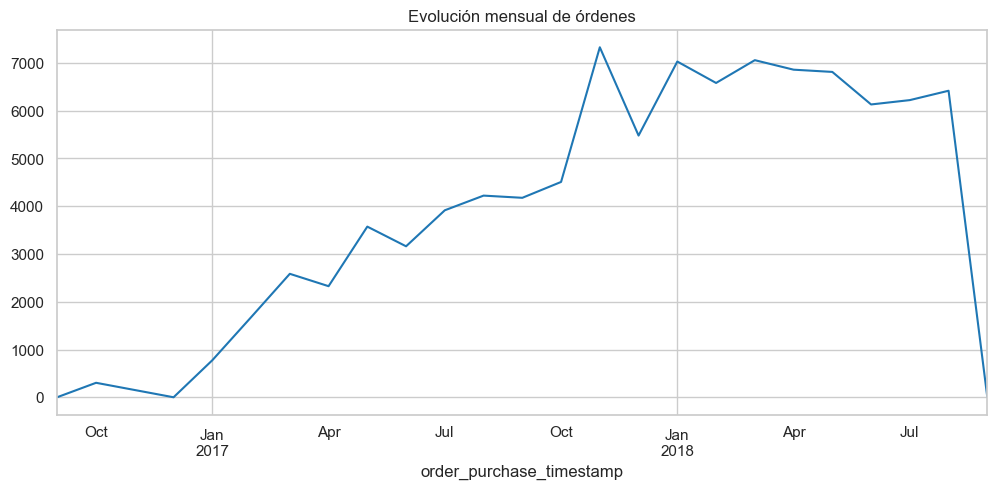

In [20]:
# =====================================
# PASO 18: ANÁLISIS TEMPORAL DE VENTAS
# =====================================

ventas_mensuales = df.groupby(
    df["order_purchase_timestamp"].dt.to_period("M")
)["order_id"].nunique()

plt.figure(figsize=(12,5))
ventas_mensuales.plot(color="#1f77b4")
plt.title("Evolución mensual de órdenes")
plt.show()

---

### Análisis temporal de la demanda

Se analiza la evolución mensual de la cantidad de órdenes con el objetivo de identificar patrones de crecimiento, estacionalidad y posibles anomalías en el comportamiento del marketplace.

#### Observaciones principales

- Se observa una **tendencia creciente** en el volumen de órdenes a lo largo del tiempo.
- Existen **picos de actividad** en determinados períodos, lo que sugiere eventos comerciales o estacionales.
- Hacia el final del período se registra una **caída abrupta**, posiblemente asociada a:
  - datos incompletos del último mes;
  - un corte temporal del dataset;
  - o un período no representativo.

💡 **Hallazgo clave:** La demanda no es estable en el tiempo, sino que presenta variaciones significativas.

### Interpretación

- El comportamiento de los usuarios es dinámico y no uniforme.
- Existen momentos de alta concentración de actividad.
- El sistema debe adaptarse a cambios en la demanda.

### Riesgos identificados

- Un modelo estático podría no capturar correctamente estas variaciones.
- Ignorar la dimensión temporal puede generar recomendaciones desactualizadas.

### Implicancias para el sistema de recomendación

- Se vuelve relevante incorporar la **recencia de las interacciones**.
- Se justifica la inclusión de variables como `days_since_last_purchase`.
- El modelo debería considerar estrategias dinámicas o actualizaciones periódicas.

____________________________________________________________________________________

In [21]:
# ============================================
# PASO 19: VALIDACIÓN ESTRUCTURAL DEL DATASET
# ============================================

n_users = df_model["customer_unique_id"].nunique()
n_products = df_model["product_id"].nunique()
n_interactions = df_model.shape[0]

density = (n_interactions / (n_users * n_products)) * 100

print(f"Usuarios únicos: {n_users}")
print(f"Productos únicos: {n_products}")
print(f"Interacciones: {n_interactions}")
print(f"Densidad: {density:.4f}%")

Usuarios únicos: 93976
Productos únicos: 32184
Interacciones: 115696
Densidad: 0.0038%


---

## Análisis de sparsity de la matriz usuario-producto

Para evaluar la viabilidad de construir un sistema de recomendación basado en comportamiento, se analiza la **densidad de la matriz usuario-producto**, es decir, la proporción de interacciones observadas respecto del total posible.

### Resultados

- **Usuarios únicos:** 93.976  
- **Productos únicos:** 32.184  
- **Interacciones observadas:** 115.696  
- **Densidad de la matriz:** 0.0038%  

💡 **Hallazgo clave:** La matriz es extremadamente dispersa.

**Interpretación**

- Más del **99.99% de las posibles interacciones no están observadas**.
- La mayoría de los usuarios interactúa con muy pocos productos.
- Existe una fuerte limitación de información por usuario.

Este comportamiento es característico de plataformas de e-commerce con catálogos amplios y baja recurrencia de compra.

### Implicancias técnicas

- Resulta difícil identificar usuarios con patrones de consumo similares.
- Los modelos basados únicamente en historial pueden presentar bajo rendimiento.
- Se manifiesta claramente el problema de **cold start**.

### Impacto en el modelado

El sistema de recomendación deberá:

- incorporar variables adicionales como:
  - popularidad del producto;
  - rating promedio;
  - recencia de compra;
- considerar enfoques más robustos como:
  - filtrado colaborativo (SVD, ALS);
  - modelos híbridos (contenido + comportamiento).

Este análisis justifica la necesidad de enriquecer el dataset más allá de las interacciones directas.

---

In [22]:
# ======================================
# PASO 20: EXPORTACIÓN DEL DATASET FINAL
# ======================================

df_model.to_csv("../data/dataset_modelo.csv", index=False)

---

## Exportación del dataset

El dataset final procesado se exporta en formato CSV para su utilización en la etapa de modelado.

Este archivo representa la versión consolidada del dataset, integrando:

- limpieza de datos,
- transformación de variables,
- generación de features,
- e integración de múltiples fuentes.

De esta manera, se asegura la reproducibilidad del pipeline y una separación clara entre las etapas de preparación de datos y modelado.

---